<a href="https://colab.research.google.com/github/laurinecharbonnier/trustpilot/blob/main/Trustpilot_LDA_Mod%C3%A9lisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librairies nécessaires
import os
import pickle
!pip install fasttext
import fasttext
import spacy
import re


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

project_path = 'drive/MyDrive/TrustPilot/'
file_name = 'dataset_final.pkl'

# chargement des données
with open(os.path.join(project_path, file_name), 'rb') as f:
    df = pickle.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# nettoyage du texte
def simple_cleantext(s):
    s = str(s).lower()
    s = re.sub(r"http\S+|www\S+", "", s)
    s = re.sub(r"\S+@\S+", "", s)
    s = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s'-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df['comment_clean'] = df['Commentaire'].apply(simple_cleantext)

In [ ]:
# Charger le modéle Fasttext pour la détection de langue
model = fasttext.load_model('drive/MyDrive/TrustPilot/lid.176.ftz')

# Prépare les textes
texts = df['comment_clean'].tolist()

labels, probs = model.predict(texts, k=2)
 # filtrer les commentaires en français
mask = []
for lbls, pbs in zip(labels, probs):
    lang1 = lbls[0] if len(lbls) > 0 else None
    lang2 = lbls[1] if len(lbls) > 1 else None
    prob1 = pbs[0] if len(pbs) > 0 else 0.0
    prob2 = pbs[1] if len(pbs) > 1 else 0.0

    # Cas 1 : langue 1 = français
    if lang1 == "__label__fr":
        mask.append(True)
    # Cas 2 : langue 2 = français avec seuils
    elif lang2 == "__label__fr" and prob1 < 0.86 and prob2 > 0.15:
        mask.append(True)
    else:
        mask.append(False)

df = df[mask].reset_index(drop=True)

In [ ]:
tfidf_path = '/content/drive/MyDrive/TrustPilot/embeddings/emb_tfidf.pkl'
print(os.path.exists(tfidf_path), os.path.getsize(tfidf_path))

True 2810439


In [ ]:
vectorizer_path = "drive/MyDrive/TrustPilot/embeddings/tfidf_vectorizer.pkl"


In [ ]:
with open(tfidf_path, "rb") as f:
    tfidf_embeddings = pickle.load(f)
with open(vectorizer_path, "rb") as f:
    vectorizer = pickle.load(f)


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

french_stopwords = stopwords.words('french')

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words=french_stopwords,
    ngram_range=(1,2),  # unigrams + bigrams
    min_df=5,
    max_df=0.95
)
tfidf_embeddings = vectorizer.fit_transform(df['comment_clean'])

# modélisation LDA

lda_model = LatentDirichletAllocation(
    n_components=10,
    learning_method='online',
    random_state=42
)

lda_model.fit(tfidf_embeddings)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


LatentDirichletAllocation(learning_method='online', random_state=42)

In [ ]:
# Afficher les top mots de chaque topic
def print_top_words(model, feature_names, n_top_words=10):
  topic_words = {}
  for topic_idx, topic in enumerate(model.components_):
      top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
      print(f"Topic {topic_idx + 1}: {', '.join(top_features)}")
      topic_words[topic_idx] = top_features
  return topic_words

feature_names = vectorizer.get_feature_names_out()
topic_words = print_top_words(lda_model, feature_names)
print_top_words(lda_model, feature_names)

Topic 1: satisfaite, très satisfaite, très, satisfaite commande, commande, parfaitement, rapide produit, respecté, produit qualité, produit
Topic 2: top, redire, rien redire, rien, impeccable, rapide, beau produit, conformes, beaux produits, conformes attentes
Topic 3: bien, trés, tres satisfaite, bien ensemble, excellente, trés bien, taille bien, satisfaite commandes, bien très, excellente qualité
Topic 4: parfait, colis, commande, service, plus, client, vente, remboursement, mois, service client
Topic 5: très, bien, livraison, très bien, produit, qualité, commande, bon, merci, rapide
Topic 6: satisfaite merci, déroulé, bien déroulé, satisfaite livraison, combinaison, reçue rapidement, article bien, courage, rapide soignée, super rien
Topic 7: conforme, description, conforme description, conforme commande, livraison temps, bien merci, commande, livraison conforme, livraison assez, conforme photos
Topic 8: attentes, nickel, conforme attentes, commande conforme, bons produits, correspon

{0: ['satisfaite',
  'très satisfaite',
  'très',
  'satisfaite commande',
  'commande',
  'parfaitement',
  'rapide produit',
  'respecté',
  'produit qualité',
  'produit'],
 1: ['top',
  'redire',
  'rien redire',
  'rien',
  'impeccable',
  'rapide',
  'beau produit',
  'conformes',
  'beaux produits',
  'conformes attentes'],
 2: ['bien',
  'trés',
  'tres satisfaite',
  'bien ensemble',
  'excellente',
  'trés bien',
  'taille bien',
  'satisfaite commandes',
  'bien très',
  'excellente qualité'],
 3: ['parfait',
  'colis',
  'commande',
  'service',
  'plus',
  'client',
  'vente',
  'remboursement',
  'mois',
  'service client'],
 4: ['très',
  'bien',
  'livraison',
  'très bien',
  'produit',
  'qualité',
  'commande',
  'bon',
  'merci',
  'rapide'],
 5: ['satisfaite merci',
  'déroulé',
  'bien déroulé',
  'satisfaite livraison',
  'combinaison',
  'reçue rapidement',
  'article bien',
  'courage',
  'rapide soignée',
  'super rien'],
 6: ['conforme',
  'description',
  'c

In [ ]:
# Taille de chaque topic
import numpy as np
import pandas as pd
#Dominant topic par document
topics = np.argmax(lda_model.transform(tfidf_embeddings), axis=1)
# Compter les documents par topic
topics_size = pd.Series(topics).value_counts().sort_index()
topics_size

,count
0,500
1,214
2,204
3,5938
4,10633
5,16
6,147
7,131
8,54
9,89


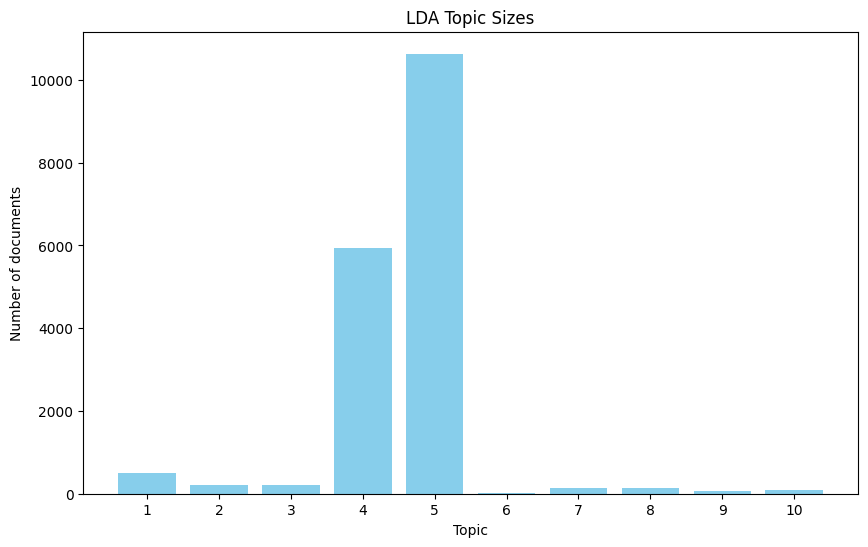

In [ ]:
# Visualisation des topics
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(topics_size.index + 1, topics_size.values, color='skyblue')
plt.xlabel('Topic')
plt.ylabel('Number of documents')
plt.title('LDA Topic Sizes')
plt.xticks(topics_size.index + 1)
plt.show()

In [ ]:
#Évaluer la diversité des topics
def topic_diversity(topic_words):
    """
    Calculate topic diversity: proportion of unique words among top words of all topics.
    """
    top_words =[]
    for topic_idx, words in topic_words.items():
        top_words.extend(words)
    unique_words = set(top_words)
    diversity = len(unique_words) / len(top_words)
    return diversity
diversity_score = topic_diversity(topic_words)

print(f"Diversité des topics: {diversity_score:.2f}") # closer to 1 : each topic uses unique words(good diversity)

Diversité des topics: 0.93
